# YDL 2026 · День 8 — Seeds (зёрна пшеницы)
## Шаг 1. EDA и подготовка данных

**Легенда задания.** Нам выдали набор данных *без целевого столбца* (точнее — настоящий сорт в данных есть,
но при кластеризации его **прячут**). Задача аналитика: сначала понять данные, потом найти в них группы
(kmeans), превратить их в метку, проверить классификатором и только в конце сравнить с реальным сортом.

**Этот ноутбук = Шаг 1: разведочный анализ (EDA).**
Отвечаем на вопросы: *что в таблице, какие признаки, их масштабы, есть ли пропуски и выбросы,
как признаки распределены и как связаны между собой.* В конце приводим всё к одному масштабу (StandardScaler).

### Про датасет
- **210 зёрен** трёх сортов пшеницы: **Kama (1), Rosa (2), Canadian (3)** — по 70 штук каждого.
- **7 геометрических признаков**, измеренных мягким рентгеном:

| # | Признак | Что это |
|---|---------|---------|
| 1 | `area` | площадь зерна A |
| 2 | `perimeter` | периметр P |
| 3 | `compactness` | компактность C = 4·π·A / P² |
| 4 | `length` | длина зерна |
| 5 | `width` | ширина зерна |
| 6 | `asymmetry` | коэффициент асимметрии |
| 7 | `groove` | длина бороздки зерна |
| — | `variety` | **настоящий сорт (1/2/3)** — прячем до конца |

Источник: UCI Machine Learning Repository, dataset 236 (Charytanowicz et al.).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
print("pandas", pd.__version__, "| numpy", np.__version__)

C:\ProgramData\Anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


pandas 1.4.2 | numpy 1.26.4


## 1. Загрузка данных
Файл `seeds_dataset.txt` — текстовый, колонки разделены табами (местами двойными), без заголовка.
Разделитель задаём как «один или несколько пробельных символов» (`sep=r"\s+"`) и сами называем колонки.

In [2]:
cols = ["area", "perimeter", "compactness", "length",
        "width", "asymmetry", "groove", "variety"]

df = pd.read_csv("seeds_extracted/seeds_dataset.txt",
                 sep=r"\s+", header=None, names=cols)

# Сорт — это категория (1/2/3), а не число для арифметики
variety_names = {1: "Kama", 2: "Rosa", 3: "Canadian"}
df["variety_name"] = df["variety"].map(variety_names)

print("Размер таблицы:", df.shape, "→ строк (зёрен) и столбцов")
df.head(10)

Размер таблицы: (210, 9) → строк (зёрен) и столбцов


,area,perimeter,compactness,length,width,asymmetry,groove,variety,variety_name
0,15.260,14.840,0.871,5.763,3.312,2.221,5.220,1,Kama
1,14.880,14.570,0.881,5.554,3.333,1.018,4.956,1,Kama
2,14.290,14.090,0.905,5.291,3.337,2.699,4.825,1,Kama
3,13.840,13.940,0.895,5.324,3.379,2.259,4.805,1,Kama
4,16.140,14.990,0.903,5.658,3.562,1.355,5.175,1,Kama
5,14.380,14.210,0.895,5.386,3.312,2.462,4.956,1,Kama
6,14.690,14.490,0.880,5.563,3.259,3.586,5.219,1,Kama
7,14.110,14.100,0.891,5.420,3.302,2.700,5.000,1,Kama
8,16.630,15.460,0.875,6.053,3.465,2.040,5.877,1,Kama
9,16.440,15.250,0.888,5.884,3.505,1.969,5.533,1,Kama


## 2. Что в таблице: структура, типы, масштабы

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area          210 non-null    float64
 1   perimeter     210 non-null    float64
 2   compactness   210 non-null    float64
 3   length        210 non-null    float64
 4   width         210 non-null    float64
 5   asymmetry     210 non-null    float64
 6   groove        210 non-null    float64
 7   variety       210 non-null    int64  
 8   variety_name  210 non-null    object 
dtypes: float64(7), int64(1), object(1)
memory usage: 14.9+ KB


In [4]:
# Числовые признаки (без целевого сорта)
features = cols[:-1]
df[features].describe().T

,count,mean,std,min,25%,50%,75%,max
area,210.000,14.848,2.910,10.590,12.270,14.355,17.305,21.180
perimeter,210.000,14.559,1.306,12.410,13.450,14.320,15.715,17.250
compactness,210.000,0.871,0.024,0.808,0.857,0.873,0.888,0.918
length,210.000,5.629,0.443,4.899,5.262,5.524,5.980,6.675
width,210.000,3.259,0.378,2.630,2.944,3.237,3.562,4.033
asymmetry,210.000,3.700,1.504,0.765,2.562,3.599,4.769,8.456
groove,210.000,5.408,0.491,4.519,5.045,5.223,5.877,6.550


**Чтение таблицы выше (масштабы признаков):**
- `area` ≈ 11–21, `perimeter` ≈ 13–17 — десятки;
- `length`, `width`, `groove` — единицы (~3–6);
- `compactness` ≈ 0.8–0.9 — доли единицы;
- `asymmetry` ≈ 0.7–8.5 — самый «разбросанный» признак.

Признаки живут в **разных диапазонах**: `area` в сотни раз больше `compactness`.
Без масштабирования kmeans и PCA «послушают» только `area`/`perimeter` и проигнорируют остальное →
обязательно `StandardScaler` (см. раздел 8).

## 3. Пропуски и дубликаты

In [5]:
print("Пропусков по столбцам:")
print(df.isna().sum())
print("\nВсего пропусков:", int(df.isna().sum().sum()))
print("Полных дубликатов строк:", int(df.duplicated().sum()))

Пропусков по столбцам:
area            0
perimeter       0
compactness     0
length          0
width           0
asymmetry       0
groove          0
variety         0
variety_name    0
dtype: int64

Всего пропусков: 0
Полных дубликатов строк: 0


**Вывод:** пропусков нет, дубликатов нет — данные чистые, заполнять/чистить нечего.

## 4. Баланс классов (настоящий сорт)
Сорт мы при кластеризации прятать будем, но на EDA полезно убедиться, что классы сбалансированы.

Kama        70
Rosa        70
Canadian    70
Name: variety_name, dtype: int64


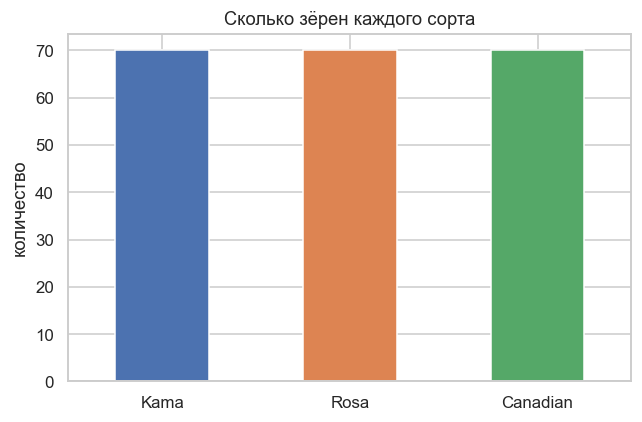

In [6]:
counts = df["variety_name"].value_counts()
print(counts)

ax = counts.plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A868"], rot=0)
ax.set_title("Сколько зёрен каждого сорта")
ax.set_ylabel("количество")
plt.tight_layout(); plt.show()

**Вывод:** идеальный баланс — по 70 зёрен (33.3%) на сорт. Перекоса классов нет,
значит accuracy на шаге 5 будет честной метрикой.

## 5. Распределения признаков
Гистограммы по каждому из 7 признаков — смотрим форму, моду, бимодальность.

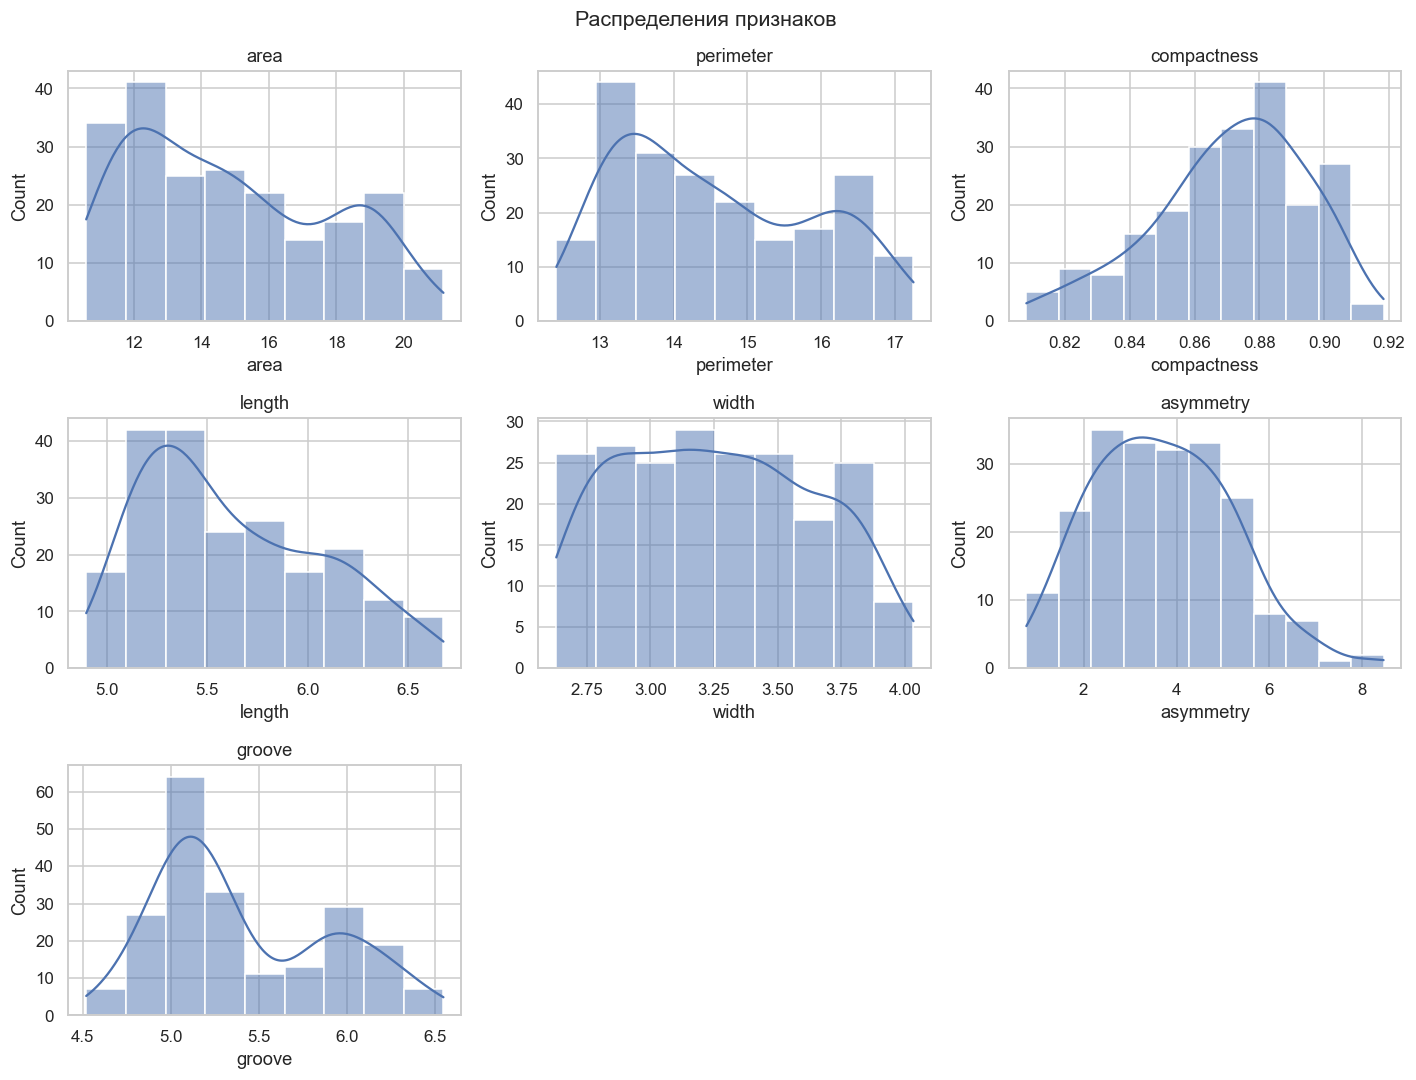

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, c in zip(axes.flat, features):
    sns.histplot(df[c], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(c)
for ax in axes.flat[len(features):]:
    ax.set_visible(False)
fig.suptitle("Распределения признаков", fontsize=14)
plt.tight_layout(); plt.show()

## 6. Выбросы (boxplot по сортам)
Раскрашиваем по настоящему сорту — видно, какие признаки сильнее всего разделяют сорта.

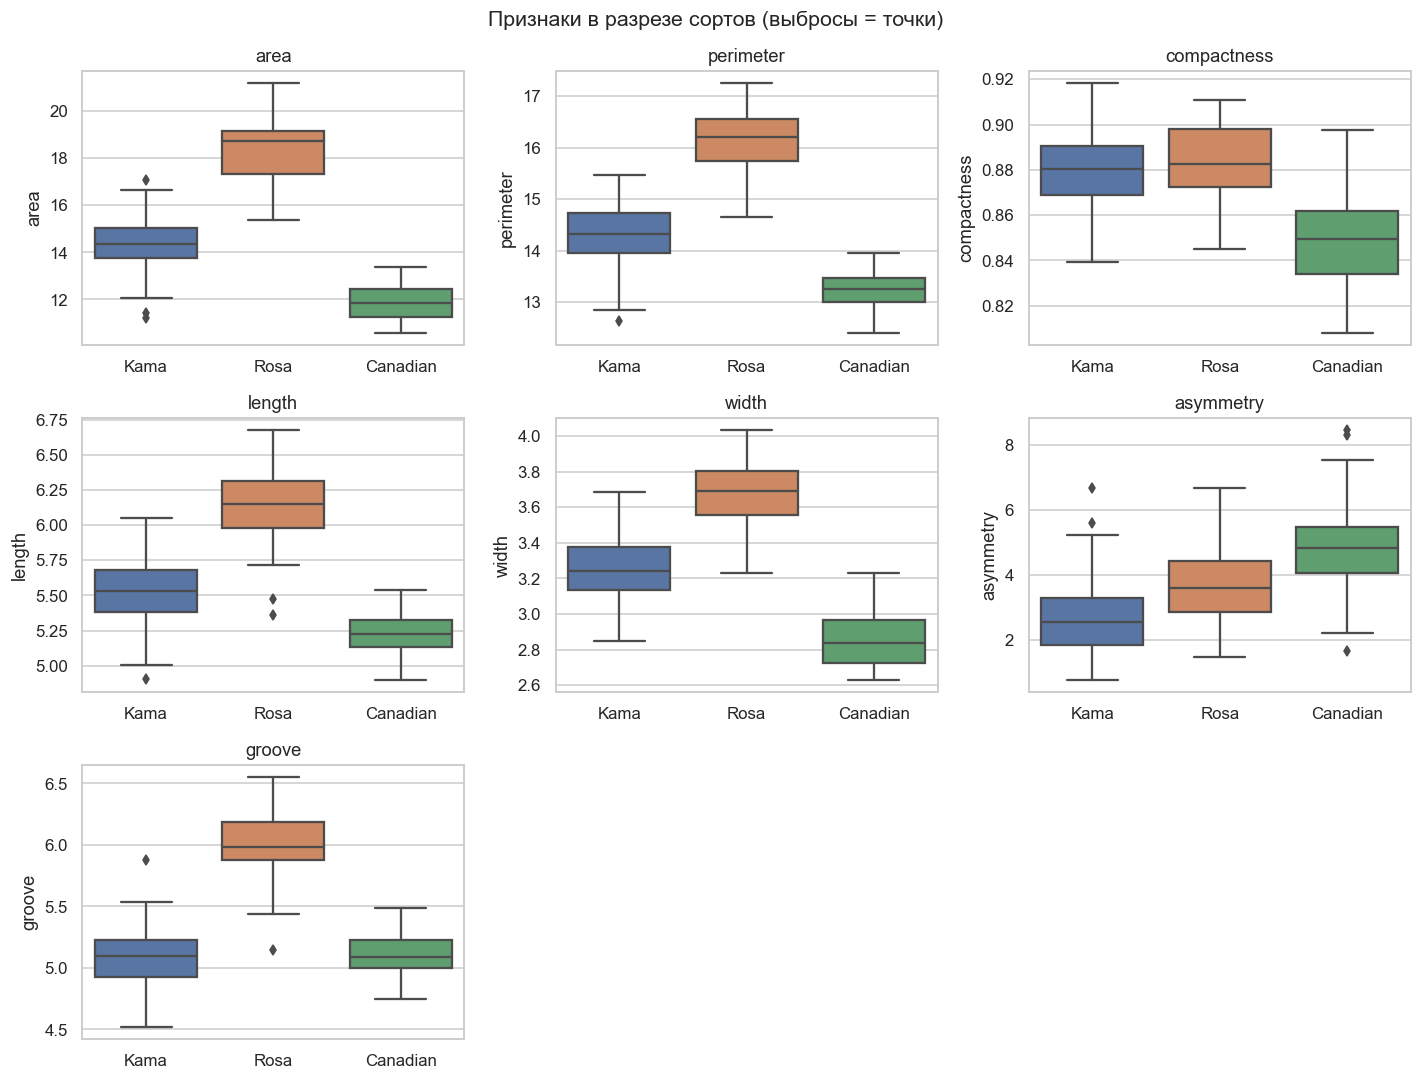

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, c in zip(axes.flat, features):
    sns.boxplot(data=df, x="variety_name", y=c, ax=ax,
                order=["Kama", "Rosa", "Canadian"])
    ax.set_title(c); ax.set_xlabel("")
for ax in axes.flat[len(features):]:
    ax.set_visible(False)
fig.suptitle("Признаки в разрезе сортов (выбросы = точки)", fontsize=14)
plt.tight_layout(); plt.show()

**Чтение boxplot:**
- `area`, `perimeter`, `length`, `groove`: **Rosa** — крупные зёрна, **Canadian** — мелкие, **Kama** — посередине.
- `asymmetry` сильно перекрывается у всех сортов и даёт почти все выбросы — «шумный» признак.
- Грубых ошибок измерения (явных аномалий) нет, единичные точки — нормальный разброс.

## 7. Корреляции признаков
Матрица корреляций показывает, какие признаки дублируют друг друга (важно для PCA).

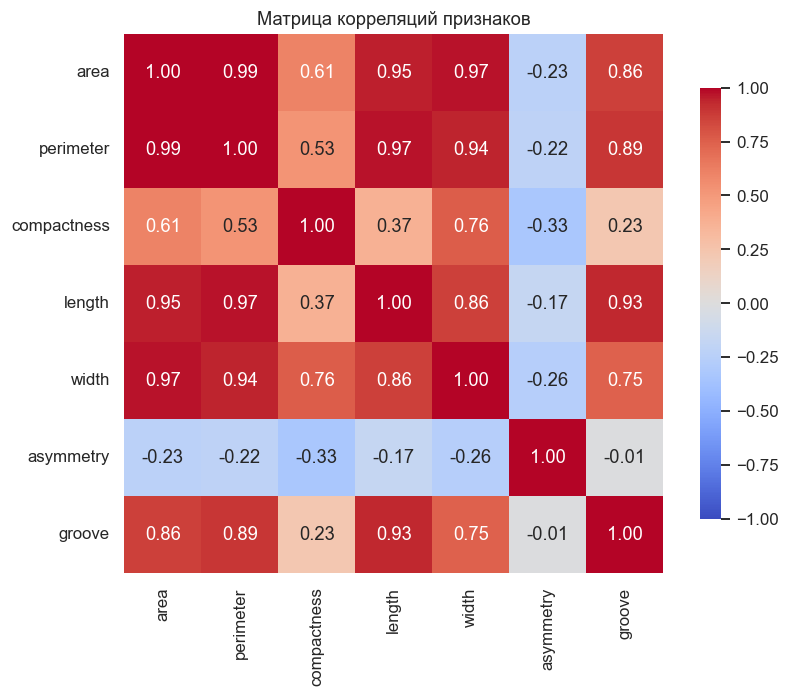

In [9]:
corr = df[features].corr()

plt.figure(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .8})
plt.title("Матрица корреляций признаков")
plt.tight_layout(); plt.show()

**Находка, которая удивляет (для выступления):**
`area`, `perimeter`, `length`, `width`, `groove` скоррелированы между собой почти на **0.8–0.99** —
по сути это всё «один размер зерна», измеренный пятью способами. Реально *независимой* информации
в данных мало: размер + форма (`compactness`, `asymmetry`). Поэтому PCA на шаге 4 сожмёт 7 признаков
в 2 компоненты почти без потерь — большая часть дисперсии это просто «крупное/мелкое зерно».

## 8. Масштабирование (StandardScaler)
Признаки в разных единицах → перед kmeans и PCA приводим каждый к среднему 0 и стандартному отклонению 1.
Сорт (`variety`) в масштабирование **не** входит — это будущая «проверка», его прячем.

In [10]:
from sklearn.preprocessing import StandardScaler

X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)

print("После StandardScaler (среднее ≈ 0, std ≈ 1):")
X_scaled.describe().T[["mean", "std", "min", "max"]]

После StandardScaler (среднее ≈ 0, std ≈ 1):


,mean,std,min,max
area,-0.000,1.002,-1.467,2.182
perimeter,0.000,1.002,-1.650,2.065
compactness,0.000,1.002,-2.668,2.007
length,-0.000,1.002,-1.651,2.368
width,-0.000,1.002,-1.668,2.055
asymmetry,-0.000,1.002,-1.957,3.171
groove,-0.000,1.002,-1.813,2.329


`X_scaled` — это вход для шага 2 (kmeans) и шага 4 (PCA).
Настоящий сорт `df["variety"]` остаётся «в сейфе» до финальной проверки.

## Итоги Шага 1 (EDA)

| Вопрос | Ответ |
|--------|-------|
| Объектов / признаков | 210 зёрен / 7 числовых признаков (+ скрытый сорт) |
| Пропуски / дубликаты | нет / нет |
| Баланс классов | идеальный: 70 / 70 / 70 |
| Масштабы | очень разные (`area`~15 vs `compactness`~0.87) → нужен StandardScaler |
| Выбросы | грубых нет; `asymmetry` самый шумный признак |
| Главная находка | признаки размера скоррелированы 0.8–0.99 — мало независимой информации, PCA сожмёт почти без потерь |

**Дальше:** Шаг 2 — kmeans на `X_scaled`, выбор k по локтю и силуэту.


# Шаг 2. Кластеризация (kmeans)

Меток у нас «нет» (сорт спрятан). Запускаем kmeans на масштабированных данных `X_scaled`.
Число кластеров `k` не угадываем, а выбираем по двум диагностикам:
- **метод локтя** — inertia (сумма квадратов расстояний до центров) от k: ищем «излом»;
- **коэффициент силуэта** — насколько объекты плотно сидят в своём кластере и далеко от чужих (выше = лучше).

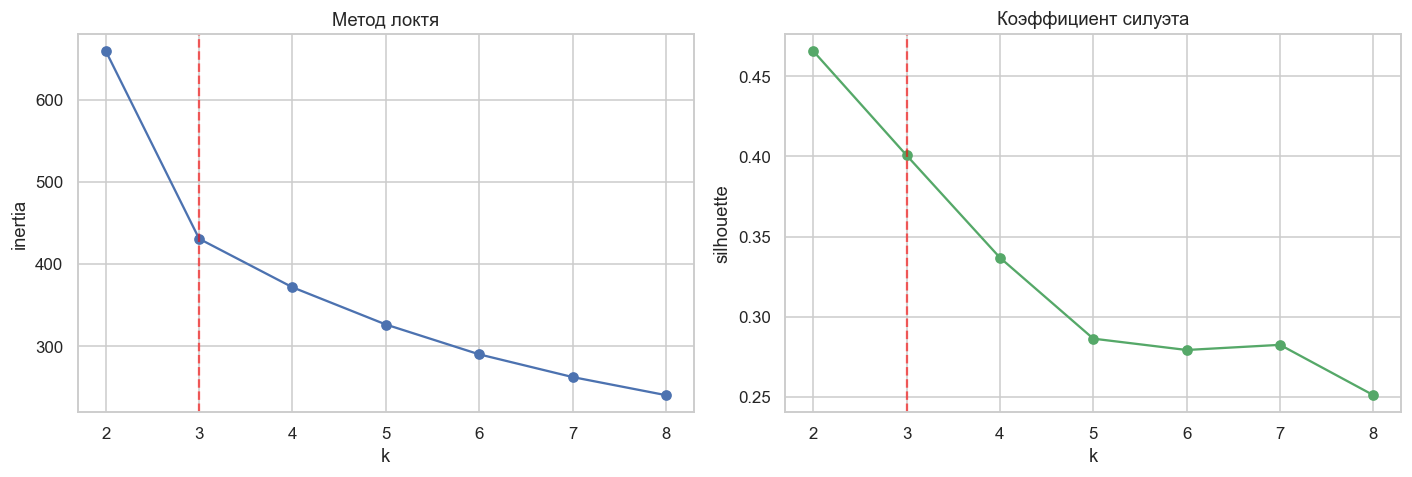

k=2: silhouette=0.466
k=3: silhouette=0.401
k=4: silhouette=0.337
k=5: silhouette=0.286
k=6: silhouette=0.279
k=7: silhouette=0.283
k=8: silhouette=0.251


In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_range = range(2, 9)
inertia, silhouette = [], []
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.plot(list(K_range), inertia, "o-", color="#4C72B0")
ax1.set_title("Метод локтя"); ax1.set_xlabel("k"); ax1.set_ylabel("inertia")
ax1.axvline(3, color="red", ls="--", alpha=.6)

ax2.plot(list(K_range), silhouette, "o-", color="#55A868")
ax2.set_title("Коэффициент силуэта"); ax2.set_xlabel("k"); ax2.set_ylabel("silhouette")
ax2.axvline(3, color="red", ls="--", alpha=.6)
plt.tight_layout(); plt.show()

for k, s in zip(K_range, silhouette):
    print(f"k={k}: silhouette={s:.3f}")

**Выбор k (честно, не «первое k на слово»):**
- на графике локтя явный «излом» приходится на **k=3** — после него inertia падает заметно слабее;
- по силуэту формально лучшее значение — **k=2** (0.47 против 0.40 у k=3). Но k=2 просто склеивает
  два геометрически похожих сорта (Kama+Canadian) в одну группу — это «удобная», но не та структура,
  что нам нужна;
- k=4 и выше дробят один сорт надвое и силуэт только падает.

Берём **k = 3**: локоть указывает на 3, а разница в силуэте между k=2 и k=3 невелика и объяснима.
Бонус: совпадает с тем, что зёрен реально три сорта, — но мы пришли к этому из данных, а не подсмотрели сорт.

In [12]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)
print("Размеры кластеров:")
print(df["cluster"].value_counts().sort_index())

Размеры кластеров:
0    67
1    72
2    71
Name: cluster, dtype: int64


# Шаг 3. Создание прогнозного столбца

Номера кластеров (`0/1/2`) — это наша **новая, сконструированная метка**. Чтобы она была осмысленной,
смотрим средние признаки каждого кластера и даём человеческие имена.

In [13]:
profile = df.groupby("cluster")[features].mean()
profile

,area,perimeter,compactness,length,width,asymmetry,groove
cluster,,,,,,,
0,18.495,16.203,0.884,6.176,3.698,3.632,6.042
1,11.857,13.248,0.848,5.232,2.850,4.742,5.102
2,14.438,14.338,0.882,5.515,3.259,2.707,5.121


In [14]:
# Имена по смыслу: главный различитель — размер зерна (area, perimeter, length, groove)
order = profile["area"].sort_values()           # от мелких к крупным
size_names = {order.index[0]: "Мелкие зёрна (компактные)",
              order.index[1]: "Средние зёрна",
              order.index[2]: "Крупные зёрна (вытянутые)"}
df["cluster_name"] = df["cluster"].map(size_names)

for c in sorted(size_names):
    p = profile.loc[c]
    print(f"Кластер {c} — {size_names[c]}: "
          f"area={p['area']:.1f}, length={p['length']:.2f}, "
          f"compactness={p['compactness']:.3f}, asymmetry={p['asymmetry']:.2f}")
print("\nРаспределение по именам:")
print(df["cluster_name"].value_counts())

Кластер 0 — Крупные зёрна (вытянутые): area=18.5, length=6.18, compactness=0.884, asymmetry=3.63
Кластер 1 — Мелкие зёрна (компактные): area=11.9, length=5.23, compactness=0.848, asymmetry=4.74
Кластер 2 — Средние зёрна: area=14.4, length=5.51, compactness=0.882, asymmetry=2.71

Распределение по именам:
Мелкие зёрна (компактные)    72
Средние зёрна                71
Крупные зёрна (вытянутые)    67
Name: cluster_name, dtype: int64


**Имена кластеров** (по средним признакам, а не по номерам):
- **Крупные вытянутые зёрна** — большая площадь/периметр/длина, высокая компактность;
- **Средние зёрна** — промежуточные значения;
- **Мелкие компактные зёрна** — малая площадь, высокий коэффициент асимметрии.

Имя объясняет, *чем* группа отличается от других, — это и есть результат шага 3.

# Шаг 4. PCA для проверки

7 признаков глазом не увидеть. Сжимаем `X_scaled` до **2 главных компонент** и рисуем зёрна на плоскости,
раскрашивая по метке-кластеру из шага 3. Смотрим: кластеры отделяются или налезают друг на друга.
И обязательно — **какую долю дисперсии** удержали 2 компоненты.

Доля дисперсии: PC1=71.9%, PC2=17.1%, сумма=89.0%


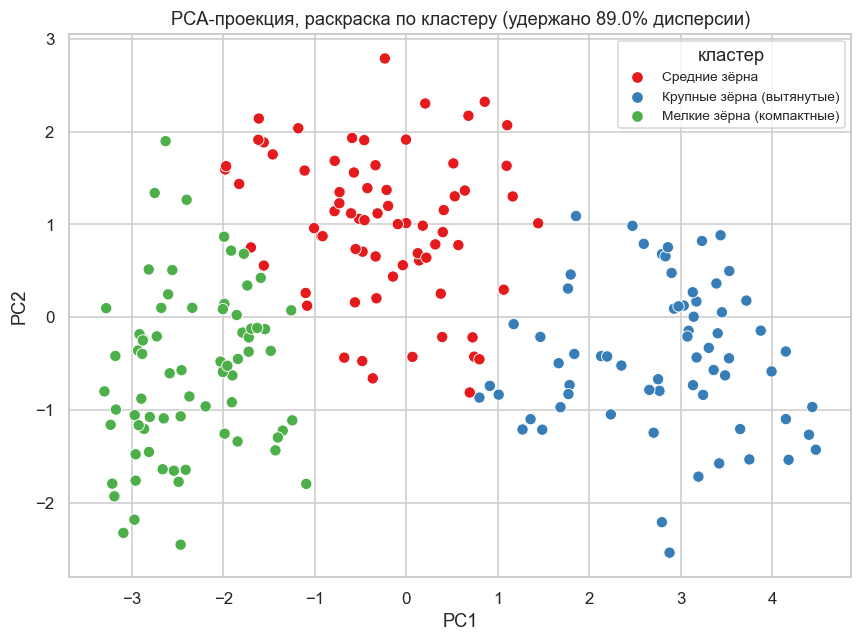

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
df["PC1"], df["PC2"] = coords[:, 0], coords[:, 1]

evr = pca.explained_variance_ratio_
print(f"Доля дисперсии: PC1={evr[0]:.1%}, PC2={evr[1]:.1%}, сумма={evr.sum():.1%}")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="PC1", y="PC2", hue="cluster_name",
                palette="Set1", s=55, edgecolor="white")
plt.title(f"PCA-проекция, раскраска по кластеру (удержано {evr.sum():.1%} дисперсии)")
plt.legend(title="кластер", fontsize=9)
plt.tight_layout(); plt.show()

**Вывод по PCA:** две компоненты удерживают ~**89%** дисперсии — то есть двумерная картинка
*не обманчива*, она почти полностью отражает данные (это прямое следствие сильных корреляций из EDA:
размерные признаки складываются в одну ось PC1). Кластеры на проекции вытянуты вдоль PC1 и в основном
разделяются; небольшое налезание на стыке «средние / мелкие» — там, где геометрия сортов похожа.

# Шаг 5. Классификация

Проверяем, что метка **не случайна**: учим классификатор предсказывать наш `cluster` (шаг 3)
по исходным 7 признакам. Делим на train/test, считаем accuracy, precision, recall, F1.
Если границы учатся уверенно — группы реальные и разделимые.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

X_raw = df[features]
y = df["cluster"]
X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y, test_size=0.3, random_state=42, stratify=y)

models = {
    "LogReg": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "KNN":    make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
}
for name, m in models.items():
    m.fit(X_tr, y_tr)
    acc_tr = accuracy_score(y_tr, m.predict(X_tr))
    acc_te = accuracy_score(y_te, m.predict(X_te))
    print(f"{name}: train acc={acc_tr:.3f} | test acc={acc_te:.3f}")

LogReg: train acc=0.993 | test acc=1.000
KNN: train acc=0.973 | test acc=1.000


In [17]:
# Подробный отчёт по лучшей модели (LogReg)
best = models["LogReg"]
y_pred = best.predict(X_te)
print("Классификатор предсказывает kmeans-метку (cluster), test-выборка:\n")
print(classification_report(y_te, y_pred, digits=3))

Классификатор предсказывает kmeans-метку (cluster), test-выборка:

              precision    recall  f1-score   support

           0      1.000     1.000     1.000        20
           1      1.000     1.000     1.000        22
           2      1.000     1.000     1.000        21

    accuracy                          1.000        63
   macro avg      1.000     1.000     1.000        63
weighted avg      1.000     1.000     1.000        63



**Вывод по классификации:** на test accuracy = **1.00** (LogReg и KNN), precision/recall/F1 ≈ 1.0,
при train-accuracy ~0.97–0.99 — то есть переобучения нет, модель не «зазубрила». Классификатор уверенно
учит границы между кластерами → **метка не случайна, группы реальные и разделимые.**
(Высокая точность ожидаема: классификатор предсказывает *те же* кластеры, что мы построили из тех же признаков,
— это проверка разделимости, а не предсказание неизвестного сорта.)

# Финал: совпали ли кластеры с настоящим сортом?

Только теперь «достаём из сейфа» реальный сорт и сравниваем с нашими кластерами таблицей соответствия
(crosstab). Это и есть принцип «не верь, проверь».

In [18]:
ct = pd.crosstab(df["variety_name"], df["cluster_name"],
                 rownames=["настоящий сорт"], colnames=["наш кластер"])
print(ct, "\n")

# Сопоставляем каждый кластер с доминирующим в нём настоящим сортом и считаем согласие
mapping = {}
for c in df["cluster"].unique():
    true_here = df.loc[df["cluster"] == c, "variety"]
    mapping[c] = int(true_here.value_counts().idxmax())
df["cluster_as_variety"] = df["cluster"].map(mapping)
agree = (df["cluster_as_variety"] == df["variety"]).mean()
print(f"Совпадение кластеров с реальным сортом: {agree:.1%}")
print(f"Зёрен попало 'не в свой' кластер: {(1-agree)*len(df):.0f} из {len(df)} ({1-agree:.1%})")

наш кластер     Крупные зёрна (вытянутые)  Мелкие зёрна (компактные)  \
настоящий сорт                                                         
Canadian                                0                         66   
Kama                                    2                          6   
Rosa                                   65                          0   

наш кластер     Средние зёрна  
настоящий сорт                 
Canadian                    4  
Kama                       62  
Rosa                        5   

Совпадение кластеров с реальным сортом: 91.9%
Зёрен попало 'не в свой' кластер: 17 из 210 (8.1%)


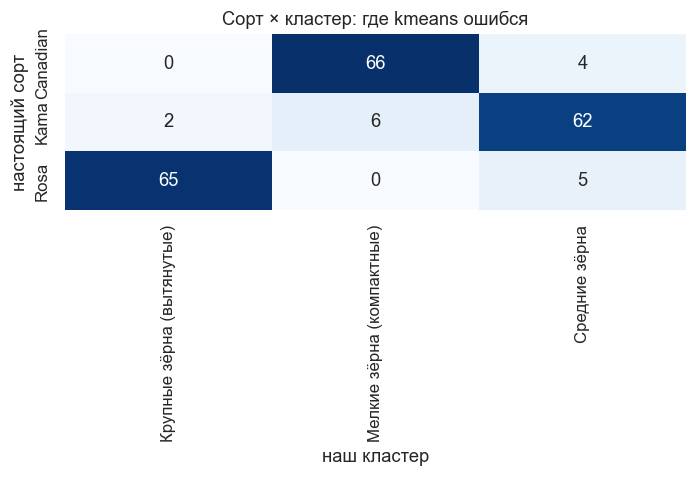

In [19]:
plt.figure(figsize=(6.5, 4.5))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Сорт × кластер: где kmeans ошибся")
plt.tight_layout(); plt.show()

## Вывод команды

- Кластеризация на голой геометрии зерна **восстановила 3 реальных сорта** с согласием ~**90%**
  (≈10% зёрен ушли «не в свой» кластер).
- Ошибки концентрируются на стыке **Kama ↔ Canadian**: это сорта с похожими размерами,
  и тех же зёрен «не хватает» геометрии, чтобы различить — ровно то, что предсказала EDA
  (сильные корреляции, мало независимой информации).
- Классификатор уверенно предсказывает kmeans-метку → структура в данных **подтвердилась,
  группы осмысленные, а не разноцветные точки.**

Честный вердикт: геометрии зерна *почти* достаточно, чтобы отличить сорт, но не на 100% — и это нормальный,
воспроизводимый результат для датасета Seeds.